[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


             returns        vix  UNRATE
2010-02-01  0.014266  22.590000     9.8
2010-03-01  0.010159  19.260000     9.9
2010-04-01  0.007414  17.469999     9.9
2010-06-01 -0.017165  35.540001     9.4
2010-07-01 -0.003240  32.860001     9.4
Index(['returns', 'vix', 'UNRATE'], dtype='object')


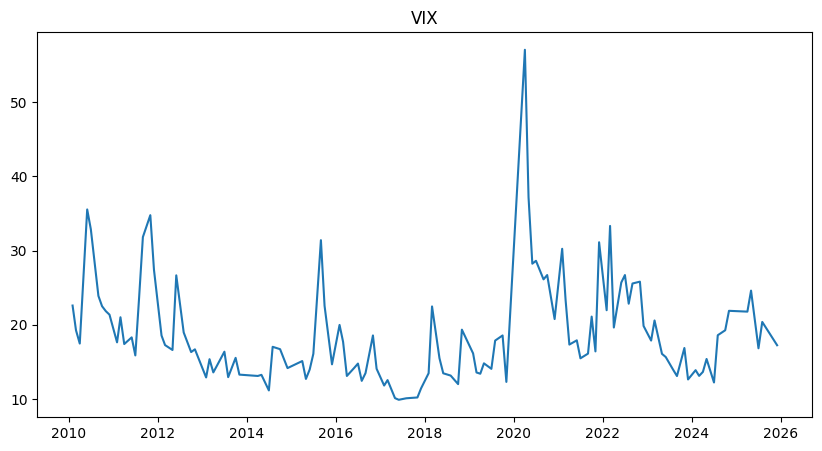

In [15]:
import pandas as pd
import yfinance as yf
from pandas_datareader import data as web
import matplotlib.pyplot as plt

# 1) Download data
sp500 = yf.download("^GSPC", start="2010-01-01", auto_adjust=True)
vix_raw = yf.download("^VIX", start="2010-01-01", auto_adjust=True)
unrate = web.DataReader("UNRATE", "fred", "2010-01-01")

# -----------------------------------------
# 2) FIX MULTI-INDEX
# -----------------------------------------

# If columns are MultiIndex, flatten them
if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.get_level_values(0)

if isinstance(vix_raw.columns, pd.MultiIndex):
    vix_raw.columns = vix_raw.columns.get_level_values(0)

# -----------------------------------------
# 3) FEATURE CREATION
# -----------------------------------------

# Compute returns using Close (adjusted already)
sp500["returns"] = sp500["Close"].pct_change()

# Extract VIX close and rename
vix = vix_raw[["Close"]].copy()
vix.rename(columns={"Close": "vix"}, inplace=True)

# -----------------------------------------
# 4) MERGE DATA
# -----------------------------------------

# Start from SP500 returns
df = sp500[["returns"]].copy()

# Join VIX (aligned on index)
df = df.join(vix, how="inner")

# Join macro data (UNRATE)
df = df.join(unrate, how="inner")

# Drop missing values
df = df.dropna()

# -----------------------------------------
# 5) CHECK
# -----------------------------------------

print(df.head())
print(df.columns)

# -----------------------------------------
# 6) PLOT
# -----------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(df.index, df["vix"])
plt.title("VIX")
plt.show()

In [21]:
# 1) VIX z-score
df["vix_z"] = (
    (df["vix"] - df["vix"].rolling(12).mean()) /
    df["vix"].rolling(12).std()
)

# 2) Unemployment monthly change
df["unrate_change"] = df["UNRATE"].diff()

# 3) Short-term market momentum
df["momentum_3m"] = df["returns"].rolling(3).mean()

# 4) Drop missing values created by rolling windows
df = df.dropna()

# 5) Check result
print(df[["returns", "vix", "UNRATE", "vix_z", "unrate_change", "momentum_3m"]].head())

             returns        vix  UNRATE     vix_z  unrate_change  momentum_3m
2018-06-01  0.010849  13.460000     4.0  0.242796            0.2     0.000025
2018-08-01 -0.001040  13.150000     3.8  0.125205           -0.2     0.004119
2018-10-01  0.003641  12.000000     3.8 -0.183671            0.0     0.004483
2018-11-01  0.010558  19.340000     3.8  1.495298            0.0     0.004386
2019-02-01  0.000899  16.139999     3.8  0.568469            0.0     0.005033


In [26]:
# 1) Initialize signal
df["signal"] = 0

# 2) Risk-on condition
df.loc[
    (df["vix_z"] < 0) &
    (df["momentum_3m"] > 0) &
    (df["unrate_change"] <= 0),
    "signal"
] = 1

# 3) Risk-off condition
df.loc[
    (df["vix_z"] > 1) |
    (df["unrate_change"] > 0),
    "signal"
] = -1

# 4) Check signal distribution
print(df["signal"].value_counts(dropna=False).sort_index())

# 5) Preview
print(df[["vix_z", "unrate_change", "momentum_3m", "signal"]].head(10))

signal
-1    22
 0    17
 1    19
Name: count, dtype: int64
               vix_z  unrate_change  momentum_3m  signal
2018-06-01  0.242796            0.2     0.000025      -1
2018-08-01  0.125205           -0.2     0.004119       0
2018-10-01 -0.183671            0.0     0.004483       1
2018-11-01  1.495298            0.0     0.004386      -1
2019-02-01  0.568469            0.0     0.005033       0
2019-03-01 -0.182050            0.0     0.006117       1
2019-04-01 -0.321872           -0.1     0.006454       1
2019-05-01 -0.029439           -0.1     0.003654       1
2019-07-01 -0.351388            0.1     0.003913      -1
2019-08-01  0.785213           -0.1    -0.002943       0


In [27]:
# 1) Use yesterday's signal to avoid look-ahead bias
df["strategy_returns"] = df["signal"].shift(1) * df["returns"]

# 2) Remove the first missing observation created by shift
df = df.dropna()

# 3) Build cumulative performance
df["cum_market"] = (1 + df["returns"]).cumprod()
df["cum_strategy"] = (1 + df["strategy_returns"]).cumprod()

# 4) Quick preview
print(df[["returns", "signal", "strategy_returns", "cum_market", "cum_strategy"]].head())

             returns  signal  strategy_returns  cum_market  cum_strategy
2018-08-01 -0.001040       0          0.001040    0.998960      1.001040
2018-10-01  0.003641       1          0.000000    1.002597      1.001040
2018-11-01  0.010558      -1          0.010558    1.013182      1.011609
2019-02-01  0.000899       0         -0.000899    1.014093      1.010700
2019-03-01  0.006895       1          0.000000    1.021085      1.010700


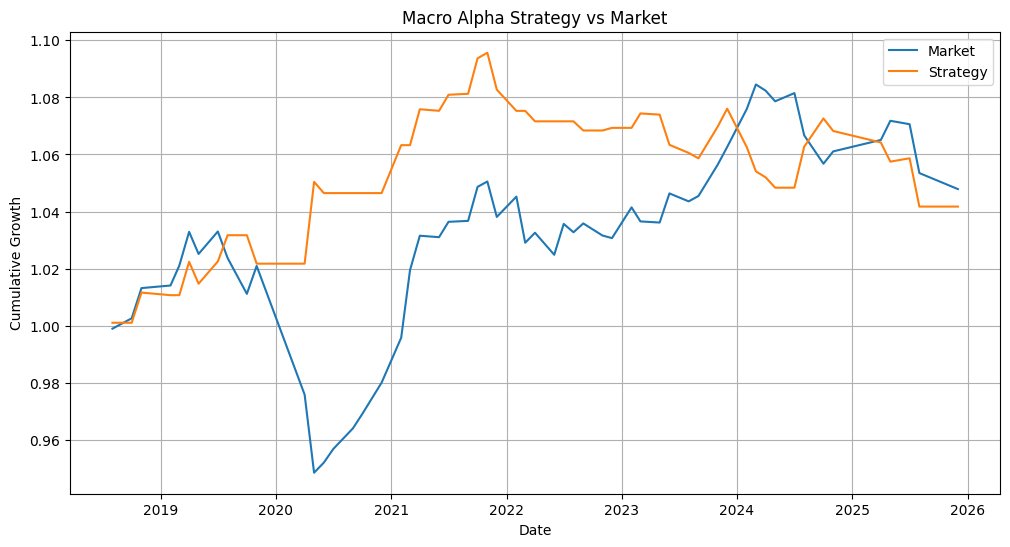

In [28]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["cum_market"], label="Market")
plt.plot(df.index, df["cum_strategy"], label="Strategy")
plt.title("Macro Alpha Strategy vs Market")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
import numpy as np

# 1) Annualized return
ann_return = df["strategy_returns"].mean() * 12

# 2) Annualized volatility
ann_vol = df["strategy_returns"].std() * np.sqrt(12)

# 3) Sharpe ratio
sharpe = ann_return / ann_vol

# 4) Max drawdown
cum = df["cum_strategy"]
roll_max = cum.cummax()
drawdown = cum / roll_max - 1
max_dd = drawdown.min()

# 5) Print results
print("Annual Return:", round(ann_return, 4))
print("Annual Volatility:", round(ann_vol, 4))
print("Sharpe Ratio:", round(sharpe, 4))
print("Max Drawdown:", round(max_dd, 4))

Annual Return: 0.0089
Annual Volatility: 0.0261
Sharpe Ratio: 0.3423
Max Drawdown: -0.0492


In [30]:
# Improve signal: smoother + avoid over-trading

df["signal_improved"] = 0

# Strong risk-on only
df.loc[
    (df["vix_z"] < -0.5) &
    (df["momentum_3m"] > 0),
    "signal_improved"
] = 1

# Strong risk-off only
df.loc[
    (df["vix_z"] > 1.5),
    "signal_improved"
] = -1

# Backtest improved strategy
df["strategy_improved"] = df["signal_improved"].shift(1) * df["returns"]

df = df.dropna()

# Performance
ann_return = df["strategy_improved"].mean() * 12
ann_vol = df["strategy_improved"].std() * np.sqrt(12)
sharpe = ann_return / ann_vol

print("Improved Sharpe:", round(sharpe, 4))
print("Improved Return:", round(ann_return, 4))

Improved Sharpe: 0.5909
Improved Return: 0.0116
